# How to Co-Morph Landmarks and Point Coordinates

When you create a cartogram, you often want other spatial objects — city markers, flow
origins, custom annotation positions — to shift consistently with the underlying geography.
`morph_gdf()` provides two arguments for this:

| Argument | Type | Use when … |
|---|---|---|
| `landmarks` | GeoDataFrame | your reference objects are already a GeoDataFrame |
| `displacement_coords` | `(N, 2)` NumPy array | you have bare `(x, y)` positions |

Both arguments are displaced by the same velocity field that morphs the main polygons.
Note that each additional set of coordinates does add some computation time per iteration,
so avoid passing unnecessarily large arrays.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

import carto_flow.data as examples
import carto_flow.flow_cartogram as flow

In [2]:
# Load US States
gdf = examples.load_us_census(population=True)

# Load world cities, filter to continental US, reproject to match census CRS
cities = examples.load_sample_cities()
us_boundary_wgs84 = gpd.GeoSeries([gdf.geometry.union_all()], crs=gdf.crs).to_crs("EPSG:4326").iloc[0]
cities_us = cities[cities.geometry.within(us_boundary_wgs84)].to_crs(gdf.crs).copy()

print(f"States: {len(gdf)}, US cities: {len(cities_us)}")

States: 49, US cities: 9


## Landmarks — co-morphing a GeoDataFrame

Pass a GeoDataFrame as `landmarks`. After morphing, retrieve the displaced geometries
with `cartogram.get_landmarks()`.

This is the right tool when your reference objects come from a GeoDataFrame — city
layers, route endpoints, or any point/line/polygon dataset whose position should follow
the distortion.

In [3]:
cartogram = flow.morph_gdf(gdf, "Population", landmarks=cities_us)
print(f"Status: {cartogram.status},  mean error: {cartogram.get_errors().mean_error_pct:.1f}%")

Morph geometries:  22%|████▍               | 112/500 [00:03<00:12, 30.74it/s, max=1.2%, mean=0.2% - converged]

Status: converged,  mean error: 0.2%


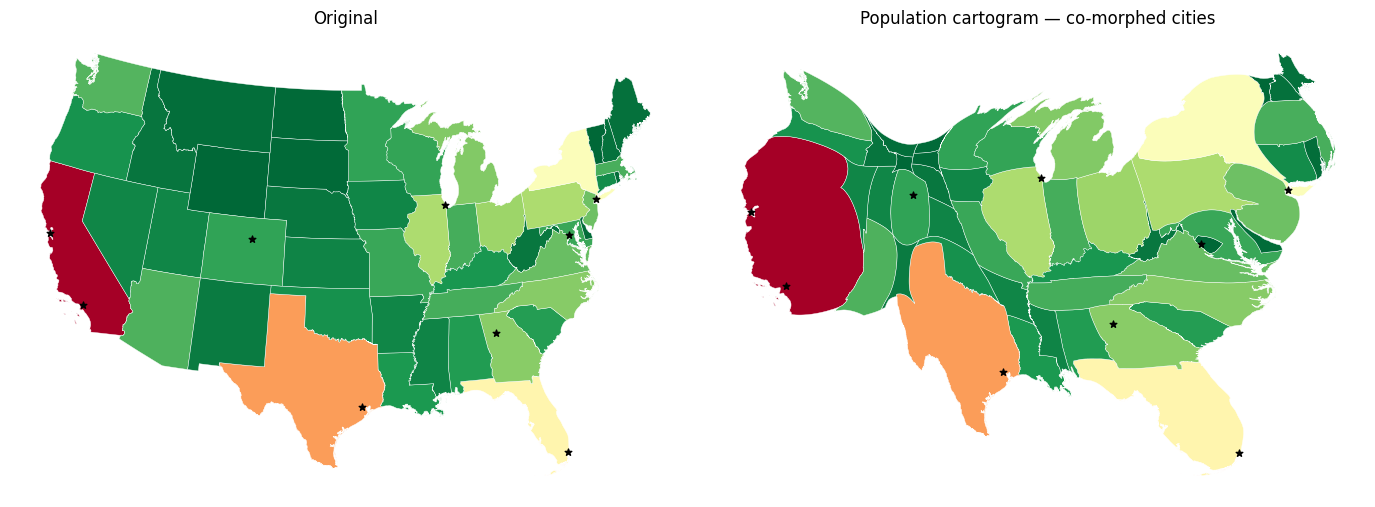

In [4]:
morphed_cities_us = cities_us.copy()
morphed_cities_us.geometry = cartogram.get_landmarks()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gdf.plot(ax=axes[0], column="Population", cmap="RdYlGn_r", edgecolor="white", linewidth=0.3)
cities_us.plot(ax=axes[0], color="k", markersize=25, zorder=5, marker="*")
axes[0].set_title("Original")
axes[0].axis("off")

cartogram.to_geodataframe().plot(
    ax=axes[1],
    column="Population",
    cmap="RdYlGn_r",
    edgecolor="white",
    linewidth=0.3,  # legend=True,
)
morphed_cities_us.plot(ax=axes[1], color="k", markersize=25, zorder=5, marker="*")
axes[1].set_title("Population cartogram — co-morphed cities")
axes[1].axis("off")

plt.tight_layout()

Notice how the cities' relative positions within their states are preserved.

## Point coordinates — co-morphing a NumPy array

When your reference positions are a bare NumPy array — annotation positions, flow
endpoints, or any `(x, y)` set not attached to a GeoDataFrame — use
`displacement_coords`. Pass an `(N, 2)` array; after morphing, retrieve the displaced
positions with `cartogram.get_coords()`. The output array has the same shape as the
input.

In the example below a regular reference grid is co-morphed alongside the cartogram.
The warped grid makes the spatial distortion easy to read at a glance.

In [5]:
bounds = gdf.total_bounds  # (minx, miny, maxx, maxy)
nx, ny = 30, 20
xs = np.linspace(bounds[0], bounds[2], nx)
ys = np.linspace(bounds[1], bounds[3], ny)
X, Y = np.meshgrid(xs, ys)
grid_coords = np.column_stack([X.ravel(), Y.ravel()])
print(f"Reference grid: {grid_coords.shape}")

Reference grid: (600, 2)


In [6]:
cartogram2 = flow.morph_gdf(
    gdf,
    "Population",
    displacement_coords=(X, Y),
)
displaced_X, displaced_Y = cartogram2.get_coords()

Morph geometries:   8%|█▋                  | 41/500 [00:00<00:03, 118.66it/s, max=1.2%, mean=0.2% - converged]


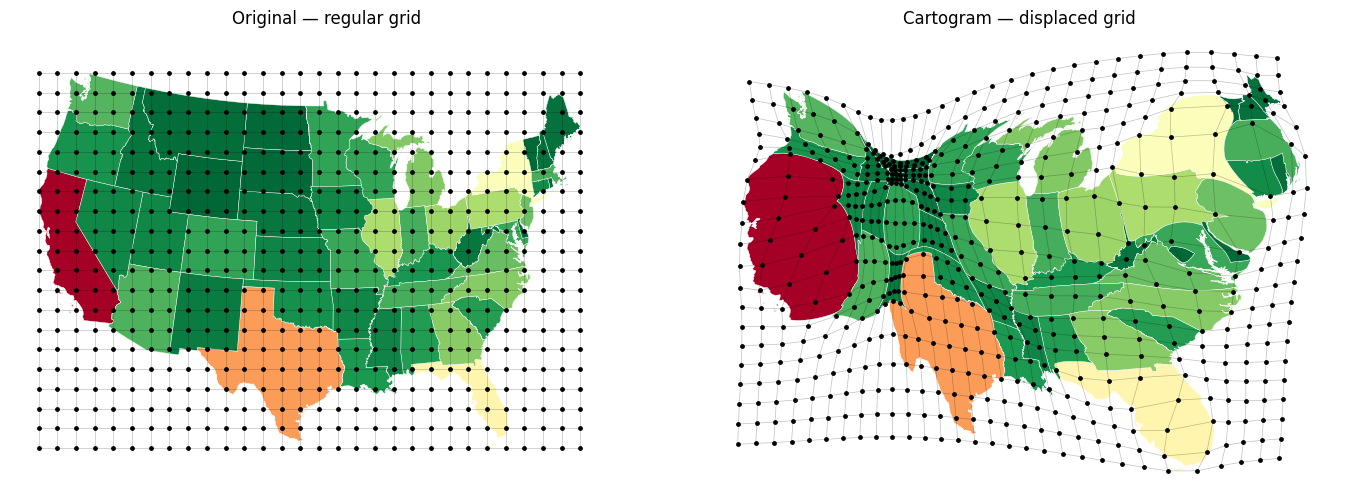

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

gdf.plot(
    ax=axes[0],
    column="Population",
    edgecolor="white",
    linewidth=0.3,
    cmap="RdYlGn_r",
)
axes[0].scatter(X, Y, s=6, c="k", zorder=5)
axes[0].plot(X, Y, "k-", lw=0.5, alpha=0.25)
axes[0].plot(X.T, Y.T, "k-", lw=0.5, alpha=0.25)
axes[0].set_title("Original — regular grid")
axes[0].axis("off")

cartogram2.to_geodataframe().plot(
    ax=axes[1],
    column="Population",
    cmap="RdYlGn_r",
    edgecolor="white",
    linewidth=0.3,
    legend=False,
)
axes[1].scatter(displaced_X, displaced_Y, s=6, c="k", zorder=5)
axes[1].plot(displaced_X, displaced_Y, "k-", lw=0.5, alpha=0.25)
axes[1].plot(displaced_X.T, displaced_Y.T, "k-", lw=0.5, alpha=0.25)
axes[1].set_title("Cartogram — displaced grid")
axes[1].axis("off")

plt.tight_layout()

## What about computing a full displacement map?

It is theoretically possible to compute something close to a pixel-level displacement
map by passing a very dense regular grid as `displacement_coords`. The displaced grid
would tell you where every location in the original CRS ends up in the cartogram.

In practice this rarely makes sense. Displacing a million-point grid at every
iteration adds substantial computation time and memory pressure — the cost scales
linearly with the number of coordinates. For most workflows it is much faster and
simpler to co-morph only the specific objects you care about:

- Use **`landmarks`** when your reference objects are in a GeoDataFrame.
- Use **`displacement_coords`** when you have a bare NumPy array of `(x, y)` positions.

Reserve the dense-grid approach for the rare case where you genuinely need a continuous
displacement field (e.g., to warp a raster image), and be prepared for the extra
computation time.